<a href="https://colab.research.google.com/github/Amyriki/PHF14-LUAD-analysis/blob/main/notebooks/02_PHF14_LUSC_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PHF14 co-expression and copy-number analysis in TCGA-LUSC

## Research question

Is the PHF14-associated chromosome 7p pattern observed in LUAD also present in lung squamous cell carcinoma (LUSC)?

## Analysis plan

1. Examine PHF14–EGFR expression correlation
2. Identify genes correlated with PHF14 expression
3. Map highly correlated genes to genomic locations
4. Examine chromosome 7 copy-number patterns
5. Test whether CNV contributes to the PHF14–EGFR expression association
6. Compare the results with TCGA-LUAD

In [4]:
!ls /content/

sample_data  TCGA.LUSC.sampleMap_HiSeqV2.gz


In [5]:
import pandas as pd

lusc = pd.read_csv(
    "/content/TCGA.LUSC.sampleMap_HiSeqV2.gz",
    sep="\t"
)

print("Dataset shape:", lusc.shape)
lusc.head()

Dataset shape: (20530, 554)


,sample,TCGA-18-3417-01,TCGA-22-4613-01,TCGA-90-7769-01,TCGA-77-A5G1-01,TCGA-77-A5G3-01,TCGA-66-2766-01,TCGA-37-4135-01,TCGA-56-8201-01,TCGA-56-7582-11,...,TCGA-77-8144-01,TCGA-J1-A4AH-01,TCGA-56-7580-01,TCGA-63-A5MY-01,TCGA-33-AASL-01,TCGA-85-A512-01,TCGA-85-8354-01,TCGA-O2-A5IB-01,TCGA-77-7335-01,TCGA-56-7731-11
0,ARHGEF10L,7.8310,8.7548,8.5936,9.9187,8.5198,8.7189,9.1261,9.2441,9.8130,...,7.6263,8.4689,7.9372,8.5287,9.1017,8.5770,8.0162,10.4325,9.0141,8.9750
1,HIF3A,4.7796,4.5313,2.2999,5.6299,6.3809,6.8616,3.5179,5.5394,8.3276,...,0.5484,9.5293,8.7095,9.5766,4.7228,3.6913,4.2574,5.5807,3.1406,9.7842
2,RNF17,1.1048,0.0000,0.4402,0.0000,0.0000,0.4815,1.3608,0.0000,3.7353,...,0.0000,1.8810,4.6888,2.0851,1.5155,0.0000,0.0000,0.6159,0.7239,0.0000
3,RNF10,12.1428,11.4508,11.9383,11.6301,11.4129,11.0799,11.0121,11.8460,11.7670,...,11.3965,11.2501,11.9486,11.4846,11.1260,11.7979,11.4975,11.7682,11.9748,11.9398
4,RNF11,11.3324,11.2760,11.3362,11.7941,10.6549,10.1758,11.5517,10.3946,11.2914,...,11.0435,10.4539,10.3632,11.4470,10.5212,10.4069,10.4076,10.8316,11.4118,11.3124


In [6]:
# Identify primary tumor samples (-01)
tumor_cols = [
    col for col in lusc.columns
    if col != "sample" and col.split("-")[3][:2] == "01"
]

print("Primary tumor samples:", len(tumor_cols))

# Keep gene names + primary tumor samples
lusc_tumor = lusc[["sample"] + tumor_cols].copy()

print("Tumor-only matrix shape:", lusc_tumor.shape)
lusc_tumor.head()

Primary tumor samples: 502
Tumor-only matrix shape: (20530, 503)


,sample,TCGA-18-3417-01,TCGA-22-4613-01,TCGA-90-7769-01,TCGA-77-A5G1-01,TCGA-77-A5G3-01,TCGA-66-2766-01,TCGA-37-4135-01,TCGA-56-8201-01,TCGA-43-7656-01,...,TCGA-58-A46L-01,TCGA-77-8144-01,TCGA-J1-A4AH-01,TCGA-56-7580-01,TCGA-63-A5MY-01,TCGA-33-AASL-01,TCGA-85-A512-01,TCGA-85-8354-01,TCGA-O2-A5IB-01,TCGA-77-7335-01
0,ARHGEF10L,7.8310,8.7548,8.5936,9.9187,8.5198,8.7189,9.1261,9.2441,9.2737,...,8.6596,7.6263,8.4689,7.9372,8.5287,9.1017,8.5770,8.0162,10.4325,9.0141
1,HIF3A,4.7796,4.5313,2.2999,5.6299,6.3809,6.8616,3.5179,5.5394,4.6673,...,7.5698,0.5484,9.5293,8.7095,9.5766,4.7228,3.6913,4.2574,5.5807,3.1406
2,RNF17,1.1048,0.0000,0.4402,0.0000,0.0000,0.4815,1.3608,0.0000,0.0000,...,2.2106,0.0000,1.8810,4.6888,2.0851,1.5155,0.0000,0.0000,0.6159,0.7239
3,RNF10,12.1428,11.4508,11.9383,11.6301,11.4129,11.0799,11.0121,11.8460,11.9948,...,11.6664,11.3965,11.2501,11.9486,11.4846,11.1260,11.7979,11.4975,11.7682,11.9748
4,RNF11,11.3324,11.2760,11.3362,11.7941,10.6549,10.1758,11.5517,10.3946,10.7864,...,10.0932,11.0435,10.4539,10.3632,11.4470,10.5212,10.4069,10.4076,10.8316,11.4118


In [7]:
print("PHF14 found:", "PHF14" in lusc_tumor["sample"].values)
print("EGFR found:", "EGFR" in lusc_tumor["sample"].values)

PHF14 found: True
EGFR found: True


In [8]:
from scipy.stats import pearsonr

# Extract PHF14 and EGFR expression
phf14 = lusc_tumor.loc[
    lusc_tumor["sample"] == "PHF14",
    tumor_cols
].iloc[0]

egfr = lusc_tumor.loc[
    lusc_tumor["sample"] == "EGFR",
    tumor_cols
].iloc[0]

print("PHF14 samples:", phf14.shape[0])
print("EGFR samples:", egfr.shape[0])

# Pearson correlation
r, p = pearsonr(phf14, egfr)

print(f"PHF14–EGFR Pearson r = {r:.3f}")
print(f"p-value = {p:.3e}")

PHF14 samples: 502
EGFR samples: 502
PHF14–EGFR Pearson r = 0.153
p-value = 5.868e-04


In [9]:
# Calculate correlation between PHF14 and every gene
correlations = lusc_tumor[tumor_cols].corrwith(phf14, axis=1)

corr_table = pd.DataFrame({
    "gene": lusc_tumor["sample"],
    "correlation": correlations
})

# Sort from strongest positive to strongest negative correlation
corr_table = corr_table.sort_values(
    "correlation",
    ascending=False
).reset_index(drop=True)

corr_table.head(20)

/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,gene,correlation
0,PHF14,1.000000
1,USP42,0.601095
2,C7orf26,0.528778
3,PMS2,0.528766
4,EIF2AK1,0.503227
5,RBAK,0.501636
6,MIOS,0.490728
7,RNF216,0.487920
8,FTSJ2,0.473478
9,CDK13,0.468747


In [10]:
# Correlation distribution
print(corr_table["correlation"].describe())

# Apply the same threshold used for LUAD
high_corr = corr_table[
    (corr_table["correlation"] >= 0.4) &
    (corr_table["gene"] != "PHF14")
].copy()

print("\nGenes with r >= 0.4:", len(high_corr))
high_corr

count    20242.000000
mean         0.016100
std          0.115537
min         -0.361005
25%         -0.062846
50%          0.013245
75%          0.092722
max          1.000000
Name: correlation, dtype: float64

Genes with r >= 0.4: 22


,gene,correlation
1,USP42,0.601095
2,C7orf26,0.528778
3,PMS2,0.528766
4,EIF2AK1,0.503227
5,RBAK,0.501636
6,MIOS,0.490728
7,RNF216,0.487920
8,FTSJ2,0.473478
9,CDK13,0.468747
10,MEX3A,0.460097


In [11]:
# PHF14-correlated genes identified in TCGA-LUAD (r >= 0.4)
luad_high_corr = {
    "FTSJ2", "TWISTNB", "USP42", "RBAK", "CCT6A",
    "EIF2AK1", "KBTBD2", "CDK13", "HNRNPA2B1",
    "ZNF12", "MIOS", "PURB", "PLEKHA8", "EIF3B",
    "KLHL7", "SP4", "SFPQ", "PMS2", "CBX3",
    "ZNF713", "GARS", "HEATR2", "SMARCC1",
    "RNF216", "SUN1", "EIF5B", "KHDRBS1"
}

lusc_high_corr = set(high_corr["gene"])

shared = luad_high_corr & lusc_high_corr
luad_only = luad_high_corr - lusc_high_corr
lusc_only = lusc_high_corr - luad_high_corr

print("LUAD high-correlation genes:", len(luad_high_corr))
print("LUSC high-correlation genes:", len(lusc_high_corr))
print("Shared genes:", len(shared))

print("\nShared:")
print(sorted(shared))

print("\nLUAD only:")
print(sorted(luad_only))

print("\nLUSC only:")
print(sorted(lusc_only))

LUAD high-correlation genes: 27
LUSC high-correlation genes: 22
Shared genes: 16

Shared:
['CDK13', 'EIF2AK1', 'EIF3B', 'FTSJ2', 'HEATR2', 'HNRNPA2B1', 'KBTBD2', 'MIOS', 'PMS2', 'RBAK', 'RNF216', 'SFPQ', 'SP4', 'TWISTNB', 'USP42', 'ZNF12']

LUAD only:
['CBX3', 'CCT6A', 'EIF5B', 'GARS', 'KHDRBS1', 'KLHL7', 'PLEKHA8', 'PURB', 'SMARCC1', 'SUN1', 'ZNF713']

LUSC only:
['C7orf26', 'MEX3A', 'PMS2CL', 'RP9', 'TNRC18', 'WIPI2']


In [12]:
!pip -q install mygene

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.1/52.1 kB 1.9 MB/s eta 0:00:00


In [13]:
import mygene

mg = mygene.MyGeneInfo()

genes = high_corr["gene"].tolist()

annotations = mg.querymany(
    genes,
    scopes="symbol",
    fields="symbol,genomic_pos",
    species="human"
)

len(annotations)

INFO:biothings.client:querying 1-22 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


22

In [14]:
# Extract chromosome information from successful annotations
annotated_genes = []

for result in annotations:
    if result.get("notfound"):
        continue

    genomic_pos = result.get("genomic_pos")

    # Some genes may have multiple genomic records
    if isinstance(genomic_pos, list):
        genomic_pos = genomic_pos[0]

    if isinstance(genomic_pos, dict):
        annotated_genes.append({
            "gene": result["query"],
            "chromosome": str(genomic_pos.get("chr")),
            "start": genomic_pos.get("start"),
            "end": genomic_pos.get("end")
        })

annotation_df = pd.DataFrame(annotated_genes)

print("Successfully annotated genes:", len(annotation_df))
print("\nGenes per chromosome:")
print(annotation_df["chromosome"].value_counts())

annotation_df

Successfully annotated genes: 18

Genes per chromosome:
chromosome
7    16
1     2
Name: count, dtype: int64


,gene,chromosome,start,end
0,USP42,7,6104755,6164429
1,PMS2,7,5970925,6009130
2,EIF2AK1,7,6022247,6059240
3,RBAK,7,5045821,5069491
4,MIOS,7,7566823,7611748
5,RNF216,7,5620047,5781696
6,CDK13,7,39950013,40099580
7,MEX3A,1,156072013,156082465
8,SP4,7,21428024,21514822
9,HNRNPA2B1,7,26169261,26201529


In [15]:
# Genes with a valid PHF14 correlation
background_genes = corr_table.loc[
    corr_table["correlation"].notna(),
    "gene"
].tolist()

print("Genes with valid correlation:", len(background_genes))

Genes with valid correlation: 20242


In [16]:
import time

background_annotations = []

batch_size = 1000

for i in range(0, len(background_genes), batch_size):
    batch = background_genes[i:i + batch_size]

    results = mg.querymany(
        batch,
        scopes="symbol",
        fields="symbol,genomic_pos",
        species="human",
        verbose=False
    )

    background_annotations.extend(results)

    print(
        f"Annotated {min(i + batch_size, len(background_genes))} "
        f"/ {len(background_genes)} genes"
    )

    time.sleep(0.2)

print("Done!")
print("Returned records:", len(background_annotations))

Annotated 1000 / 20242 genes
Annotated 2000 / 20242 genes
Annotated 3000 / 20242 genes
Annotated 4000 / 20242 genes
Annotated 5000 / 20242 genes
Annotated 6000 / 20242 genes
Annotated 7000 / 20242 genes
Annotated 8000 / 20242 genes
Annotated 9000 / 20242 genes
Annotated 10000 / 20242 genes
Annotated 11000 / 20242 genes
Annotated 12000 / 20242 genes
Annotated 13000 / 20242 genes
Annotated 14000 / 20242 genes
Annotated 15000 / 20242 genes
Annotated 16000 / 20242 genes
Annotated 17000 / 20242 genes
Annotated 18000 / 20242 genes
Annotated 19000 / 20242 genes
Annotated 20000 / 20242 genes
Annotated 20242 / 20242 genes
Done!
Returned records: 20603


In [17]:
# Clean background annotations
background_rows = []

for result in background_annotations:

    # Skip genes with no annotation
    if result.get("notfound"):
        continue

    genomic_pos = result.get("genomic_pos")

    # If multiple genomic positions exist, use the first one
    if isinstance(genomic_pos, list):
        genomic_pos = genomic_pos[0]

    if not isinstance(genomic_pos, dict):
        continue

    chromosome = str(genomic_pos.get("chr"))

    # Keep standard chromosomes only
    valid_chromosomes = [str(i) for i in range(1, 23)] + ["X", "Y"]

    if chromosome not in valid_chromosomes:
        continue

    background_rows.append({
        "gene": result["query"],
        "chromosome": chromosome
    })

background_df = pd.DataFrame(background_rows)

# One row per input gene
background_df = background_df.drop_duplicates(subset="gene")

print("Valid annotated background genes:", len(background_df))

print("\nBackground genes per chromosome:")
print(background_df["chromosome"].value_counts().sort_index())

Valid annotated background genes: 16794

Background genes per chromosome:
chromosome
1     1747
10     623
11    1140
12     900
13     272
14     505
15     499
16     692
17    1009
18     225
19    1227
2     1071
20     457
21     180
22     381
3      940
4      633
5      769
6      805
7      773
8      557
9      627
X      703
Y       59
Name: count, dtype: int64


In [18]:
from scipy.stats import hypergeom

# Background
M = len(background_df)
K = (background_df["chromosome"] == "7").sum()

# PHF14 high-correlation genes with valid annotations
N = len(annotation_df)
k = (annotation_df["chromosome"] == "7").sum()

# Hypergeometric enrichment test:
# probability of observing k or more chr7 genes
p_enrichment = hypergeom.sf(k - 1, M, K, N)

print("Background genes:", M)
print("Background chr7 genes:", K)
print(f"Background chr7 proportion: {K/M:.3%}")

print("\nPHF14-correlated annotated genes:", N)
print("Observed chr7 genes:", k)
print(f"Observed chr7 proportion: {k/N:.3%}")

print("\nExpected chr7 genes by chance:", N * K / M)
print(f"Hypergeometric enrichment p-value: {p_enrichment:.3e}")

Background genes: 16794
Background chr7 genes: 773
Background chr7 proportion: 4.603%

PHF14-correlated annotated genes: 18
Observed chr7 genes: 16
Observed chr7 proportion: 88.889%

Expected chr7 genes by chance: 0.8285101822079314
Hypergeometric enrichment p-value: 4.905e-20


### Chromosome 7 enrichment

Among 18 successfully annotated genes with PHF14 expression correlation ≥ 0.4,
16 (88.9%) were located on chromosome 7. In contrast, chromosome 7 genes
represented only 4.6% of the analyzable gene background (773/16,794).

A hypergeometric test showed strong enrichment of chromosome 7 genes
among PHF14-correlated genes (p = 4.91 × 10⁻²⁰).

This non-random genomic concentration raises the possibility that shared
chromosomal alterations, such as copy-number variation, contribute to the
observed co-expression pattern.

## Copy-number analysis

The strong enrichment of PHF14-correlated genes on chromosome 7 suggests
that their coordinated expression may reflect a shared genomic alteration.

We therefore asked whether copy-number variation across chromosome 7 could
contribute to the observed PHF14-associated expression pattern.

### Analysis plan

1. Obtain gene-level copy-number data for TCGA-LUSC
2. Examine chromosome 7 copy-number concordance with PHF14
3. Compare copy-number patterns between chromosome 7p and 7q
4. Examine PHF14–EGFR copy-number concordance
5. Test whether PHF14 and EGFR copy number is associated with their expression
6. Re-evaluate the PHF14–EGFR expression correlation after accounting for CNV

In [19]:
!ls /content/

sample_data
TCGA.LUSC.sampleMap_Gistic2_CopyNumber_Gistic2_all_thresholded.by_genes.gz
TCGA.LUSC.sampleMap_HiSeqV2.gz


In [20]:
cnv = pd.read_csv(
    "/content/TCGA.LUSC.sampleMap_Gistic2_CopyNumber_Gistic2_all_thresholded.by_genes.gz",
    sep="\t"
)

print("CNV matrix shape:", cnv.shape)
cnv.head()

CNV matrix shape: (24776, 502)


,Gene Symbol,TCGA-18-3406-01,TCGA-18-3407-01,TCGA-18-3408-01,TCGA-18-3409-01,TCGA-18-3410-01,TCGA-18-3411-01,TCGA-18-3412-01,TCGA-18-3414-01,TCGA-18-3415-01,...,TCGA-NK-A5CX-01,TCGA-NK-A5D1-01,TCGA-NK-A7XE-01,TCGA-O2-A52N-01,TCGA-O2-A52Q-01,TCGA-O2-A52S-01,TCGA-O2-A52V-01,TCGA-O2-A52W-01,TCGA-O2-A5IB-01,TCGA-XC-AA0X-01
0,ACAP3,1,0,-1,-1,0,-1,1,-1,-1,...,0,0,0,-1,-1,-1,-1,0,1,0
1,ACTRT2,1,0,-1,-1,0,-1,1,-1,-1,...,0,0,0,-1,-1,-1,-1,0,1,0
2,AGRN,1,0,-1,-1,0,-1,1,-1,-1,...,0,0,0,-1,-1,-1,-1,0,1,0
3,ANKRD65,1,0,-1,-1,0,-1,1,-1,-1,...,0,0,0,-1,-1,-1,-1,0,1,0
4,ATAD3A,1,0,-1,-1,0,-1,1,-1,-1,...,0,0,0,-1,-1,-1,-1,0,1,0


In [21]:
print("First column:", cnv.columns[0])

print("\nPHF14 found:",
      "PHF14" in cnv.iloc[:, 0].values)

print("EGFR found:",
      "EGFR" in cnv.iloc[:, 0].values)

# What CNV values actually occur?
cnv_values = pd.unique(
    cnv.iloc[:, 1:].values.ravel()
)

print("\nUnique CNV values:")
print(sorted(cnv_values))

First column: Gene Symbol

PHF14 found: True
EGFR found: True

Unique CNV values:
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]


In [22]:
# Number of genes in the CNV matrix
cnv_genes = cnv["Gene Symbol"].dropna().astype(str).unique().tolist()

print("CNV genes:", len(cnv_genes))
print(cnv_genes[:10])

CNV genes: 24776
['ACAP3', 'ACTRT2', 'AGRN', 'ANKRD65', 'ATAD3A', 'ATAD3B', 'ATAD3C', 'AURKAIP1', 'B3GALT6', 'C1orf159']


In [23]:
import mygene
import pandas as pd

mg = mygene.MyGeneInfo()

cnv_annotations = []

batch_size = 1000

for i in range(0, len(cnv_genes), batch_size):
    batch = cnv_genes[i:i + batch_size]

    result = mg.querymany(
        batch,
        scopes="symbol",
        fields="symbol,genomic_pos",
        species="human",
        as_dataframe=False
    )

    cnv_annotations.extend(result)

    print(
        f"Annotated {min(i + batch_size, len(cnv_genes))} / "
        f"{len(cnv_genes)} genes"
    )

print("Done!")
print("Returned records:", len(cnv_annotations))

INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.
INFO:biothings.client:querying 1-1000 ...


Annotated 1000 / 24776 genes


INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.
INFO:biothings.client:querying 1-1000 ...


Annotated 2000 / 24776 genes


INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.
INFO:biothings.client:querying 1-1000 ...


...

Annotated 23000 / 24776 genes


INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.
INFO:biothings.client:querying 1-776 ...


Annotated 24000 / 24776 genes


INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


Annotated 24776 / 24776 genes
Done!
Returned records: 25552


In [24]:
# Convert MyGene results into a clean genomic-position table

records = []

for item in cnv_annotations:
    # Skip genes without a genomic position
    if item.get("notfound") or "genomic_pos" not in item:
        continue

    pos = item["genomic_pos"]

    # Sometimes genomic_pos contains multiple records
    if isinstance(pos, list):
        pos = pos[0]

    if not isinstance(pos, dict):
        continue

    chrom = str(pos.get("chr", ""))

    # Keep standard chromosomes only
    if chrom not in [str(i) for i in range(1, 23)] + ["X", "Y"]:
        continue

    start = pos.get("start")
    end = pos.get("end")

    if start is None or end is None:
        continue

    records.append({
        "gene": item.get("query"),
        "chromosome": chrom,
        "start": start,
        "end": end,
        "position_mb": ((start + end) / 2) / 1e6
    })

cnv_annotation_df = pd.DataFrame(records)

# One genomic record per input gene
cnv_annotation_df = (
    cnv_annotation_df
    .drop_duplicates(subset="gene")
    .reset_index(drop=True)
)

print("Successfully annotated genes:", len(cnv_annotation_df))

cnv_annotation_df.head()

Successfully annotated genes: 21310


,gene,chromosome,start,end,position_mb
0,ACAP3,1,1292376,1309609,1.300992
1,ACTRT2,1,3021467,3022903,3.022185
2,AGRN,1,1020069,1056119,1.038094
3,ANKRD65,1,1415637,1421769,1.418703
4,ATAD3A,1,1512118,1534689,1.523403


In [25]:
print(
    cnv_annotation_df[
        cnv_annotation_df["gene"].isin(["PHF14", "EGFR"])
    ]
)

print("\nChromosome 7 genes:")
print((cnv_annotation_df["chromosome"] == "7").sum())

       gene chromosome     start       end  position_mb
7576  PHF14          7  10973327  11169623    11.071475
7801   EGFR          7  55018820  55211628    55.115224

Chromosome 7 genes:
986


In [26]:
from scipy.stats import spearmanr
import pandas as pd

# Sample columns in the CNV matrix
cnv_sample_cols = cnv.columns[1:]

# Extract PHF14 CNV across all LUSC samples
phf14_cnv = (
    cnv.loc[cnv["Gene Symbol"] == "PHF14", cnv_sample_cols]
    .iloc[0]
    .astype(float)
)

# Keep chromosome 7 genes and sort by genomic position
chr7_map = (
    cnv_annotation_df[
        cnv_annotation_df["chromosome"] == "7"
    ]
    .sort_values("position_mb")
    .copy()
)

results = []

for _, row in chr7_map.iterrows():

    gene = row["gene"]

    gene_rows = cnv.loc[
        cnv["Gene Symbol"] == gene,
        cnv_sample_cols
    ]

    # Skip if the gene is not present or duplicated in CNV matrix
    if len(gene_rows) != 1:
        continue

    gene_cnv = gene_rows.iloc[0].astype(float)

    rho, p = spearmanr(phf14_cnv, gene_cnv)

    results.append({
        "gene": gene,
        "position_mb": row["position_mb"],
        "rho_with_PHF14_CNV": rho,
        "p_value": p
    })

chr7_cnv_corr = pd.DataFrame(results).sort_values("position_mb")

print("Chromosome 7 genes analysed:", len(chr7_cnv_corr))

chr7_cnv_corr.head(10)

Chromosome 7 genes analysed: 986


,gene,position_mb,rho_with_PHF14_CNV,p_value
0,FAM20C,0.226404,0.838524,1.088469e-133
1,PDGFA,0.508981,0.838524,1.088469e-133
2,PRKAR1B,0.638732,0.844875,1.146502e-137
3,SUN1,0.856513,0.858557,7.045201e-147
4,GET4,0.886463,0.859632,1.212549e-147
5,ADAP1,0.925872,0.859632,1.212549e-147
6,COX19,0.970201,0.859632,1.212549e-147
7,CYP2W1,0.986408,0.859632,1.212549e-147
8,MIR339,1.022979,0.859632,1.212549e-147
9,GPR146,1.051906,0.859632,1.212549e-147


In [27]:
chr7_cnv_corr[
    chr7_cnv_corr["gene"].isin(["PHF14", "EGFR"])
]

,gene,position_mb,rho_with_PHF14_CNV,p_value
83,PHF14,11.071475,1.000000,0.000000e+00
308,EGFR,55.115224,0.619283,2.216174e-54


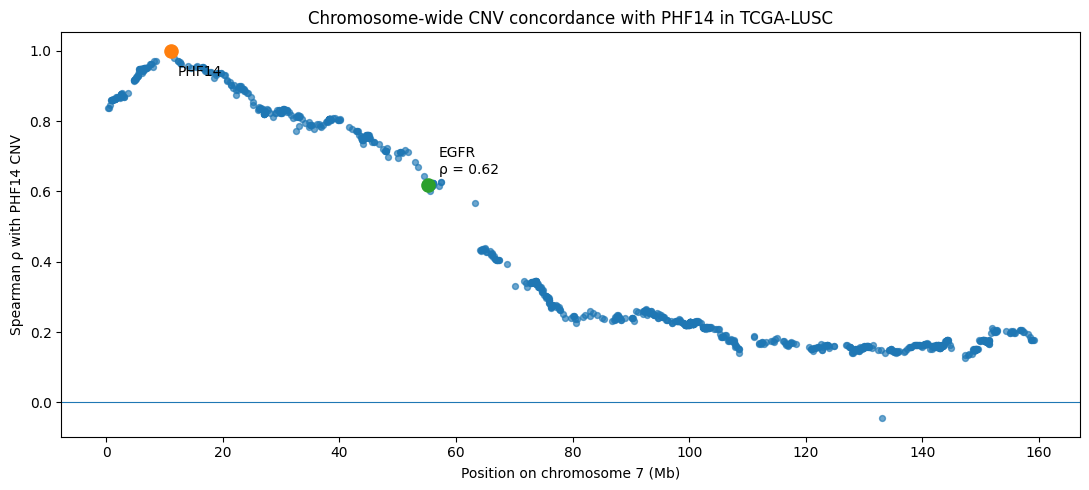

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 5))

plt.scatter(
    chr7_cnv_corr["position_mb"],
    chr7_cnv_corr["rho_with_PHF14_CNV"],
    s=18,
    alpha=0.65
)

# PHF14
phf14_point = chr7_cnv_corr[
    chr7_cnv_corr["gene"] == "PHF14"
].iloc[0]

plt.scatter(
    phf14_point["position_mb"],
    phf14_point["rho_with_PHF14_CNV"],
    s=90,
    zorder=5
)

plt.annotate(
    "PHF14",
    (phf14_point["position_mb"],
     phf14_point["rho_with_PHF14_CNV"]),
    xytext=(5, -18),
    textcoords="offset points"
)

# EGFR
egfr_point = chr7_cnv_corr[
    chr7_cnv_corr["gene"] == "EGFR"
].iloc[0]

plt.scatter(
    egfr_point["position_mb"],
    egfr_point["rho_with_PHF14_CNV"],
    s=90,
    zorder=5
)

plt.annotate(
    f"EGFR\nρ = {egfr_point['rho_with_PHF14_CNV']:.2f}",
    (egfr_point["position_mb"],
     egfr_point["rho_with_PHF14_CNV"]),
    xytext=(8, 8),
    textcoords="offset points"
)

plt.xlabel("Position on chromosome 7 (Mb)")
plt.ylabel("Spearman ρ with PHF14 CNV")
plt.title("Chromosome-wide CNV concordance with PHF14 in TCGA-LUSC")

plt.axhline(0, linewidth=0.8)

plt.tight_layout()
plt.show()

In [29]:
# Approximate chromosome 7 arm boundary
# Keep the same boundary definition as in the LUAD analysis
centromere_boundary = 60

chr7_cnv_corr["arm"] = chr7_cnv_corr["position_mb"].apply(
    lambda x: "7p" if x < centromere_boundary else "7q"
)

arm_summary = (
    chr7_cnv_corr
    .groupby("arm")["rho_with_PHF14_CNV"]
    .agg(["count", "mean", "median", "std"])
)

arm_summary

,count,mean,median,std
arm,,,,
7p,321,0.832718,0.828758,0.087621
7q,665,0.213179,0.200756,0.068819


In [30]:
from scipy.stats import mannwhitneyu

p_arm = chr7_cnv_corr.loc[
    chr7_cnv_corr["arm"] == "7p",
    "rho_with_PHF14_CNV"
]

q_arm = chr7_cnv_corr.loc[
    chr7_cnv_corr["arm"] == "7q",
    "rho_with_PHF14_CNV"
]

u_stat, p_value = mannwhitneyu(
    p_arm,
    q_arm,
    alternative="greater"
)

print("7p median rho:", p_arm.median())
print("7q median rho:", q_arm.median())
print("Mann–Whitney U:", u_stat)
print("p-value:", p_value)

7p median rho: 0.8287584536904642
7q median rho: 0.20075589478264103
Mann–Whitney U: 213465.0
p-value: 1.992300516719523e-143


### Interim conclusion: PHF14 CNV concordance extends across chromosome 7p

Chromosome-wide analysis revealed strong CNV concordance between PHF14 and genes across chromosome 7p in TCGA-LUSC. Concordance was highest near the PHF14 locus and generally decreased with genomic distance, with substantially lower correlations across chromosome 7q.

EGFR, located at approximately 55 Mb on chromosome 7p, showed a strong positive CNV correlation with PHF14 (Spearman ρ = 0.619). However, this relationship occurs within a broader 7p-wide pattern rather than representing an isolated PHF14–EGFR association.

These results suggest that the PHF14–EGFR CNV correlation should be interpreted in the context of shared chromosome 7p copy-number alterations.

In [31]:
# Expression sample IDs
expr_samples = set(tumor_cols)

# CNV sample IDs
cnv_sample_cols = cnv.columns[1:]
cnv_samples = set(cnv_sample_cols)

# Shared samples
common_samples = sorted(expr_samples & cnv_samples)

print("Expression tumor samples:", len(expr_samples))
print("CNV samples:", len(cnv_samples))
print("Common samples:", len(common_samples))

print("\nExpression-only samples:")
print(sorted(expr_samples - cnv_samples)[:20])

print("\nCNV-only samples:")
print(sorted(cnv_samples - expr_samples)[:20])

Expression tumor samples: 502
CNV samples: 501
Common samples: 498

Expression-only samples:
['TCGA-33-4579-01', 'TCGA-37-A5EM-01', 'TCGA-51-6867-01', 'TCGA-77-8146-01']

CNV-only samples:
['TCGA-34-2604-01', 'TCGA-34-2605-01', 'TCGA-34-2609-01']


In [33]:
# Extract PHF14 and EGFR CNV values for the 498 matched samples
phf14_cnv = cnv.loc[
    cnv["Gene Symbol"] == "PHF14",
    common_samples
].iloc[0]

egfr_cnv = cnv.loc[
    cnv["Gene Symbol"] == "EGFR",
    common_samples
].iloc[0]

# Expression values for exactly the same samples
phf14_expr = phf14[common_samples]
egfr_expr = egfr[common_samples]

# Build paired sample-level table
paired = pd.DataFrame({
    "PHF14_expression": phf14_expr,
    "PHF14_CNV": phf14_cnv,
    "EGFR_expression": egfr_expr,
    "EGFR_CNV": egfr_cnv
})

print("Paired samples:", paired.shape)
paired.head()

Paired samples: (498, 4)


,PHF14_expression,PHF14_CNV,EGFR_expression,EGFR_CNV
TCGA-18-3406-01,9.7350,1,10.4522,0
TCGA-18-3407-01,9.9049,1,11.0627,1
TCGA-18-3408-01,9.4274,1,13.2873,2
TCGA-18-3409-01,9.8559,1,10.5041,1
TCGA-18-3410-01,10.1585,0,10.2131,0


In [34]:
from scipy.stats import spearmanr

rho_phf14, p_phf14 = spearmanr(
    paired["PHF14_CNV"],
    paired["PHF14_expression"]
)

print("PHF14 CNV vs expression")
print(f"n = {len(paired)}")
print(f"Spearman rho = {rho_phf14:.3f}")
print(f"p-value = {p_phf14:.3e}")

print("\nExpression by PHF14 CNV state:")
print(
    paired.groupby("PHF14_CNV")["PHF14_expression"]
    .agg(["count", "mean", "median", "std"])
)

PHF14 CNV vs expression
n = 498
Spearman rho = 0.413
p-value = 5.680e-22

Expression by PHF14 CNV state:
           count       mean    median       std
PHF14_CNV                                      
-2             1   9.732500   9.73250       NaN
-1            60   9.118663   9.11525  0.565488
 0           183   9.627137   9.58990  0.507852
 1           247   9.859061   9.84480  0.479252
 2             7  10.858586  10.60490  0.712468


In [35]:
rho_egfr, p_egfr = spearmanr(
    paired["EGFR_CNV"],
    paired["EGFR_expression"]
)

print("EGFR CNV vs expression")
print(f"n = {len(paired)}")
print(f"Spearman rho = {rho_egfr:.3f}")
print(f"p-value = {p_egfr:.3e}")

print("\nExpression by EGFR CNV state:")
print(
    paired.groupby("EGFR_CNV")["EGFR_expression"]
    .agg(["count", "mean", "median", "std"])
)

EGFR CNV vs expression
n = 498
Spearman rho = 0.430
p-value = 7.224e-24

Expression by EGFR CNV state:
          count       mean    median       std
EGFR_CNV                                      
-2            2   9.502200   9.50220  0.349594
-1           52   9.776106  10.04085  1.335875
 0          190  10.642867  10.88465  1.277327
 1          219  11.014688  11.10350  1.299824
 2           35  13.742800  13.72210  1.426532


In [36]:
from scipy.stats import spearmanr

rho_cnv, p_cnv = spearmanr(
    paired["PHF14_CNV"],
    paired["EGFR_CNV"]
)

print("PHF14 CNV vs EGFR CNV")
print(f"n = {len(paired)}")
print(f"Spearman rho = {rho_cnv:.3f}")
print(f"p-value = {p_cnv:.3e}")

print("\nCNV state cross-tabulation:")
print(
    pd.crosstab(
        paired["PHF14_CNV"],
        paired["EGFR_CNV"]
    )
)

PHF14 CNV vs EGFR CNV
n = 498
Spearman rho = 0.618
p-value = 8.276e-54

CNV state cross-tabulation:
EGFR_CNV   -2  -1    0    1   2
PHF14_CNV                      
-2          0   0    1    0   0
-1          1  36    8    7   8
 0          0   7  156   12   8
 1          1   9   25  196  16
 2          0   0    0    4   3


### Interim conclusion: PHF14 and EGFR show substantial copy-number concordance

Across 498 matched TCGA-LUSC tumor samples, PHF14 and EGFR copy-number states were strongly correlated (Spearman ρ = 0.618, p = 8.28 × 10⁻⁵⁴).

The cross-tabulation also showed that many tumors shared the same or similar copy-number states at the two loci.

Together with the chromosome-wide analysis, this pattern is consistent with shared copy-number alterations across chromosome 7p rather than, by itself, evidence of a direct functional relationship between PHF14 and EGFR.

In [37]:
from scipy.stats import pearsonr
import statsmodels.api as sm

# 1. Raw PHF14–EGFR expression correlation
raw_r, raw_p = pearsonr(
    paired["PHF14_expression"],
    paired["EGFR_expression"]
)

# 2. Remove the expression variation associated with BOTH CNVs
X = paired[["PHF14_CNV", "EGFR_CNV"]]
X = sm.add_constant(X)

model_phf14 = sm.OLS(
    paired["PHF14_expression"],
    X
).fit()

model_egfr = sm.OLS(
    paired["EGFR_expression"],
    X
).fit()

phf14_residual = model_phf14.resid
egfr_residual = model_egfr.resid

# 3. Correlate the remaining expression variation
adjusted_r, adjusted_p = pearsonr(
    phf14_residual,
    egfr_residual
)

print("PHF14–EGFR expression correlation")
print(f"n = {len(paired)}")

print("\nRaw:")
print(f"Pearson r = {raw_r:.3f}")
print(f"p-value = {raw_p:.3e}")

print("\nAfter accounting for PHF14 and EGFR CNV:")
print(f"Pearson r = {adjusted_r:.3f}")
print(f"p-value = {adjusted_p:.3e}")

PHF14–EGFR expression correlation
n = 498

Raw:
Pearson r = 0.158
p-value = 4.180e-04

After accounting for PHF14 and EGFR CNV:
Pearson r = 0.129
p-value = 3.989e-03


LUAD
- PHF14–EGFR CNV：ρ ≈ 0.738
- expression raw：r = 0.185
- CNV-adjusted：r = 0.092

LUSC
- PHF14–EGFR CNV：ρ ≈ 0.618
- expression raw：r = 0.158
- CNV-adjusted：r = 0.129

In [38]:
import pandas as pd

comparison = pd.DataFrame({
    "Analysis": [
        "PHF14–EGFR CNV correlation",
        "PHF14 CNV–expression correlation",
        "EGFR CNV–expression correlation",
        "PHF14–EGFR expression correlation",
        "CNV-adjusted PHF14–EGFR expression correlation"
    ],
    "LUAD": [
        0.738,
        0.408,
        0.427,
        0.185,
        0.092
    ],
    "LUSC": [
        0.618,
        0.413,
        0.430,
        0.158,
        0.129
    ]
})

comparison

,Analysis,LUAD,LUSC
0,PHF14–EGFR CNV correlation,0.738,0.618
1,PHF14 CNV–expression correlation,0.408,0.413
2,EGFR CNV–expression correlation,0.427,0.430
3,PHF14–EGFR expression correlation,0.185,0.158
4,CNV-adjusted PHF14–EGFR expression correlation,0.092,0.129


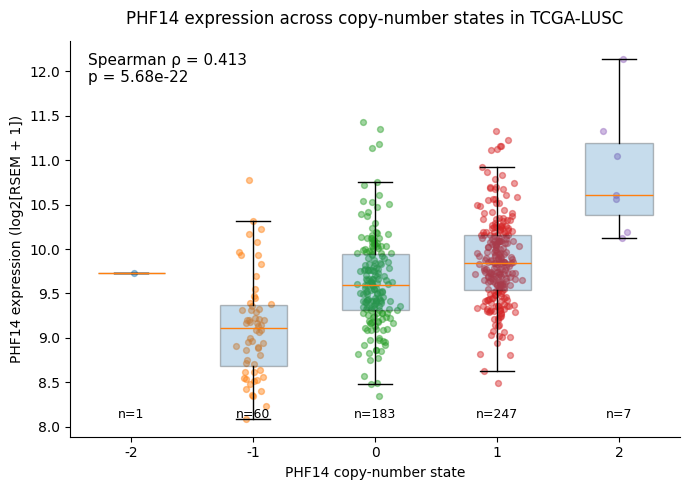

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# CNV states in fixed order
states = [-2, -1, 0, 1, 2]

fig, ax = plt.subplots(figsize=(7, 5))

# Prepare data
data = [
    paired.loc[paired["PHF14_CNV"] == state, "PHF14_expression"].dropna()
    for state in states
]

# Boxplot
bp = ax.boxplot(
    data,
    positions=range(len(states)),
    widths=0.55,
    patch_artist=True,
    showfliers=False
)

# Keep styling simple
for box in bp["boxes"]:
    box.set_alpha(0.25)

# Add individual samples with jitter
rng = np.random.default_rng(42)

for i, values in enumerate(data):
    x = rng.normal(i, 0.07, size=len(values))
    ax.scatter(
        x,
        values,
        s=18,
        alpha=0.45
    )

# Sample sizes
y_min, y_max = ax.get_ylim()
offset = (y_max - y_min) * 0.04

for i, values in enumerate(data):
    ax.text(
        i,
        y_min + offset,
        f"n={len(values)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Statistics
ax.text(
    0.03,
    0.97,
    f"Spearman ρ = {rho_phf14:.3f}\n"
    f"p = {p_phf14:.2e}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11
)

ax.set_xticks(range(len(states)))
ax.set_xticklabels(states)

ax.set_xlabel("PHF14 copy-number state")
ax.set_ylabel("PHF14 expression (log2[RSEM + 1])")

ax.set_title(
    "PHF14 expression across copy-number states in TCGA-LUSC",
    pad=12
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

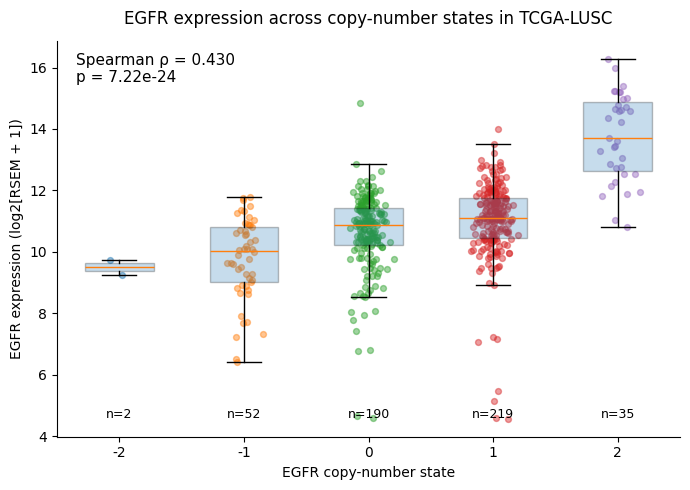

In [40]:
# EGFR expression across CNV states

states = [-2, -1, 0, 1, 2]

fig, ax = plt.subplots(figsize=(7, 5))

data = [
    paired.loc[paired["EGFR_CNV"] == state, "EGFR_expression"].dropna()
    for state in states
]

# Boxplot
bp = ax.boxplot(
    data,
    positions=range(len(states)),
    widths=0.55,
    patch_artist=True,
    showfliers=False
)

for box in bp["boxes"]:
    box.set_alpha(0.25)

# Individual samples
rng = np.random.default_rng(42)

for i, values in enumerate(data):
    x = rng.normal(i, 0.07, size=len(values))
    ax.scatter(
        x,
        values,
        s=18,
        alpha=0.45
    )

# Sample sizes
y_min, y_max = ax.get_ylim()
offset = (y_max - y_min) * 0.04

for i, values in enumerate(data):
    ax.text(
        i,
        y_min + offset,
        f"n={len(values)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Statistics
ax.text(
    0.03,
    0.97,
    f"Spearman ρ = {rho_egfr:.3f}\n"
    f"p = {p_egfr:.2e}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11
)

ax.set_xticks(range(len(states)))
ax.set_xticklabels(states)

ax.set_xlabel("EGFR copy-number state")
ax.set_ylabel("EGFR expression (log2[RSEM + 1])")

ax.set_title(
    "EGFR expression across copy-number states in TCGA-LUSC",
    pad=12
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

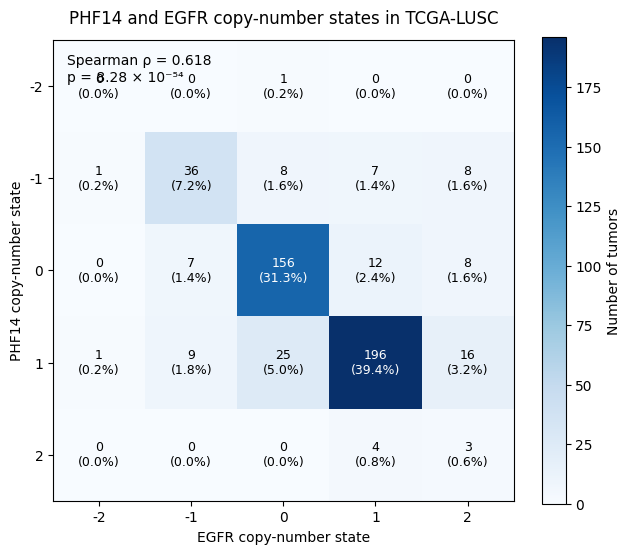

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# PHF14 × EGFR CNV state table
cnv_table = pd.crosstab(
    paired["PHF14_CNV"],
    paired["EGFR_CNV"]
)

# Make sure all five states are shown
states = [-2, -1, 0, 1, 2]

cnv_table = cnv_table.reindex(
    index=states,
    columns=states,
    fill_value=0
)

# Percentage of all paired samples
cnv_pct = cnv_table / cnv_table.values.sum() * 100

fig, ax = plt.subplots(figsize=(6.5, 5.5))

im = ax.imshow(
    cnv_table.values,
    cmap="Blues"
)

# Count + percentage in each cell
threshold = cnv_table.values.max() * 0.45

for i in range(len(states)):
    for j in range(len(states)):
        count = cnv_table.iloc[i, j]
        pct = cnv_pct.iloc[i, j]

        ax.text(
            j, i,
            f"{count}\n({pct:.1f}%)",
            ha="center",
            va="center",
            fontsize=9,
            color="white" if count > threshold else "black"
        )

ax.set_xticks(range(len(states)))
ax.set_yticks(range(len(states)))

ax.set_xticklabels(states)
ax.set_yticklabels(states)

ax.set_xlabel("EGFR copy-number state")
ax.set_ylabel("PHF14 copy-number state")

ax.set_title(
    "PHF14 and EGFR copy-number states in TCGA-LUSC",
    pad=12
)

# Statistics
ax.text(
    0.03,
    0.97,
    "Spearman ρ = 0.618\n"
    "p = 8.28 × 10⁻⁵⁴",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Number of tumors")

plt.tight_layout()
plt.show()